In [ ]:
!pip install mygene
!pip install gseapy
!pip install pyvis

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

import mygene
import gseapy as gp
from gseapy.plot import barplot
from gseapy.plot import dotplot

import requests
import networkx as nx

# Tradução de Identificadores

In [7]:
genes_up = pd.read_csv('/content/drive/MyDrive/cancer-BRCA/datasets/genes_up.csv', index_col=0)

ensembl_ids = genes_up.index.tolist()
ensembl_ids = [gene.split('.')[0] for gene in ensembl_ids]

print(f"Temos {len(ensembl_ids)} genes para traduzir.")

ensembl_ids[:5]

Temos 4374 genes para traduzir.


['ENSG00000000460',
 'ENSG00000001617',
 'ENSG00000002079',
 'ENSG00000002726',
 'ENSG00000003249']

In [8]:
mg = mygene.MyGeneInfo()

gene_symbols = mg.querymany(ensembl_ids,
                       scopes='ensembl.gene',
                       fields='symbol,name',
                       species='human',
                       as_dataframe=True
                      )

gene_symbols = gene_symbols.dropna(subset=['symbol'])

gene_symbols.head()

INFO:biothings.client:querying 1-1000 ...
INFO:biothings.client:querying 1001-2000 ...
INFO:biothings.client:querying 2001-3000 ...
INFO:biothings.client:querying 3001-4000 ...
INFO:biothings.client:querying 4001-4374 ...
INFO:biothings.client:Finished.
INFO:biothings.client:Pass "returnall=True" to return complete lists of duplicate or missing query terms.


,_id,_score,name,symbol,notfound
query,,,,,
ENSG00000000460,55732,31.881956,FIGNL1 interacting regulator of recombination ...,FIRRM,NaN
ENSG00000001617,6405,31.881956,semaphorin 3F,SEMA3F,NaN
ENSG00000002726,26,31.881956,amine oxidase copper containing 1,AOC1,NaN
ENSG00000003249,79007,32.888676,dysbindin domain containing 1,DBNDD1,NaN
ENSG00000003989,6542,31.881943,solute carrier family 7 member 2,SLC7A2,NaN


# Dicionário Biológico

## 1. Gene Ontology (GO):
<font size=3>
    
O Gene Ontology é um projeto colaborativo massivo que visa padronizar a forma como descrevemos a função dos genes em qualquer organismo (de bactérias a humanos). Ele divide a biologia em três grandes categorias:

* **Processo Biológico (*Biological Process* — BP):**
    * Descreve o objetivo final e amplo em que o gene está envolvido.
    <br>

* **Função Molecular (*Molecular Function* — MF):**
    * Descreve a atividade bioquímica exata da proteína em nível molecular.
    <br>

* **Componente Celular (*Cellular Component* — CC):**
    * Descreve em qual parte da célula a proteína atua.
    <br>

## 2. KEGG Pathways:
<font size=3>
    
Enquanto o Gene Ontology nos dá etiquetas organizadas, o KEGG nos dá mapas. Na biologia, as proteínas raramente trabalham sozinhas. Elas agem em cascatas ou circuitos de sinalização (a Proteína A ativa a B, que inibe a C, que entra no núcleo...). O KEGG mapeia esses circuitos.


> Em resumo: o **GO** categoriza as funções, e o **KEGG** mapeia as interações em vias sistêmicas.


# Análise de Super-Representação

In [9]:
enr = gp.enrichr(gene_list=gene_symbols['symbol'].tolist(),
                 gene_sets=['KEGG_2021_Human', 'GO_Biological_Process_2021'],
                 organism='human',
                 outdir=None,
                 cutoff=0.05
                )

ora_results = enr.results
ora_results.head()

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,KEGG_2021_Human,Systemic lupus erythematosus,52/135,6.935252e-08,0.000021,0,0,2.724475,44.910412,H2AX;CD80;H2AC16;H2AC17;C4B;H2AC11;C4A;H2AC12;...
1,KEGG_2021_Human,Alcoholism,62/186,1.662534e-06,0.000256,0,0,2.174676,28.938779,H2AX;CALML5;HDAC11;H2AC16;H2AC17;H2AC11;GNGT1;...
2,KEGG_2021_Human,Cell cycle,40/124,2.390225e-04,0.024540,0,0,2.064003,17.211626,PCNA;BUB1B;TTK;PKMYT1;ANAPC11;CDC20;CCNB2;CCNB...
3,KEGG_2021_Human,Neutrophil extracellular trap formation,55/189,3.888318e-04,0.029940,0,0,1.780708,13.982770,H2AX;HDAC11;ITGAL;H2AC16;H2AC17;H2AC11;H2AC12;...
4,KEGG_2021_Human,Fanconi anemia pathway,18/54,7.998198e-03,0.492689,0,0,2.160886,10.433921,FANCI;RMI2;BLM;CENPX;RMI1;FANCA;FAAP24;BRCA1;F...


## Visualização dos Resultados
<font size=3>

O gráfico de barras é uma forma direta de visualizar as vias mais alteradas. O tamanho da barra é o nível de significância ($-\log_{10}$ do p-valor ajustado).

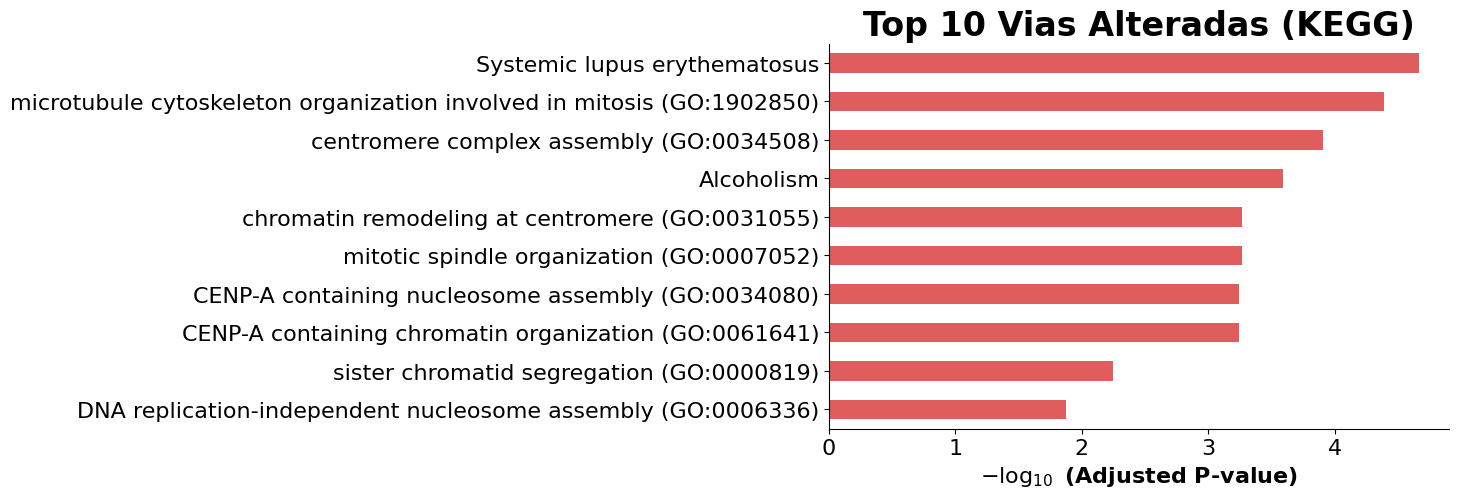

In [10]:
ax = barplot(enr.results,
             column="Adjusted P-value",
             group='KEGG_2021_Human',
             size=10,
             top_term=10,
             figsize=(8, 5),
             color='tab:red',
             title="Top 10 Vias Alteradas (KEGG)"
            )

plt.show()

<font size=3>
<br>
    
Podemos também plotar o gráfico de pontos, que nos mostra três informações simultaneamente:
  * **Eixo Y:** O nome da via.
  * **Tamanho do ponto:** O número de genes da nossa lista que estão nessa via (*Count*).
  * **Cor do Ponto:** A significância estatística (P-valor ajustado).

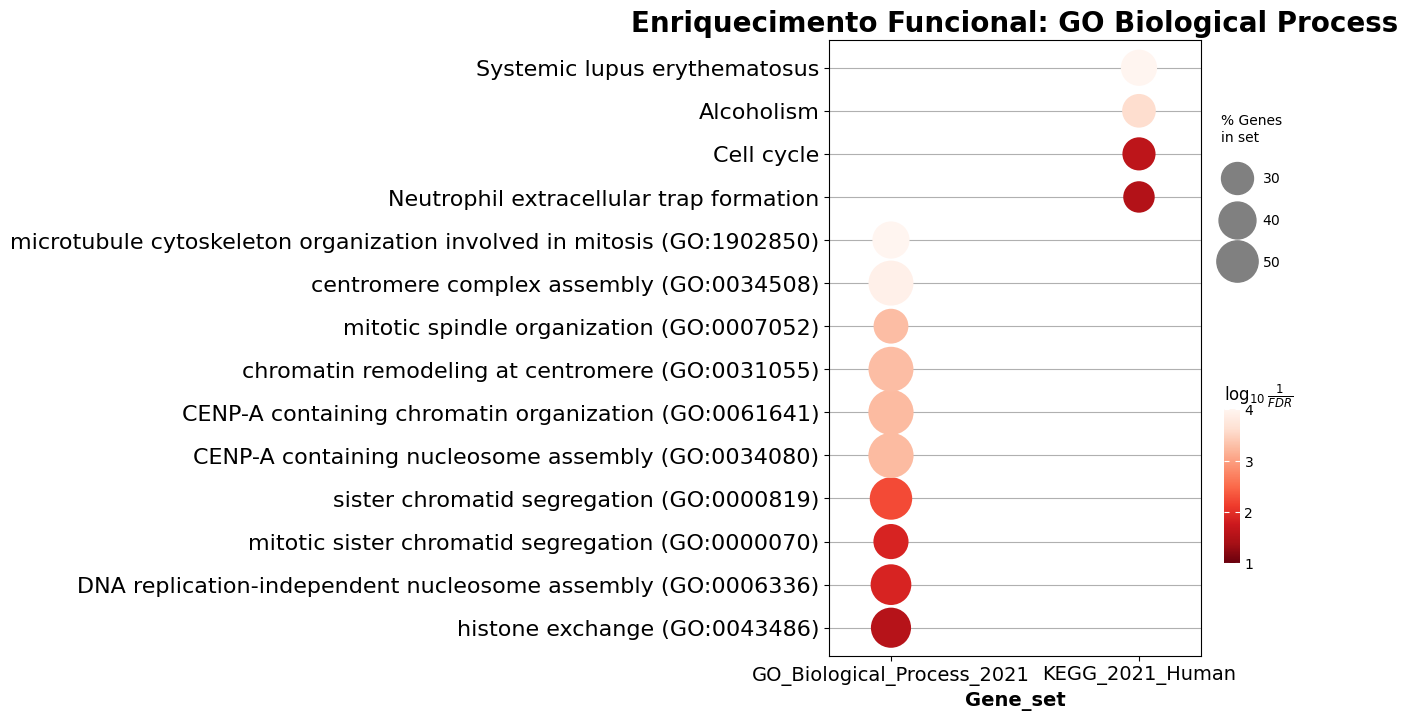

In [23]:
ax = dotplot(enr.results,
             column="Adjusted P-value",
             x='Gene_set',
             size=7,
             top_term=10,
             figsize=(6, 8),
             title="Enriquecimento Funcional: GO Biological Process",
             cmap='Reds_r'
            )

plt.show()

# Redes e Interação
<font size=3>

Até agora, identificamos quais genes estão alterados e em quais vias biológicas eles atuam. Para aprofundar nossa análise, vamos investigar como os produtos desses genes se organizam na prática para exercer as funções celulares.

<font size=3>

Afinal, quando um gene é lido, ele produz uma proteína. E para que uma via biológica realmente funcione, a Proteína A frequentemente precisa se ligar fisicamente à Proteína B, que por sua vez ativa a Proteína C. Essa teia de contatos físicos é o que chamamos de Rede de Interação Proteína-Proteína (Protein-Protein Interaction — PPI).

In [12]:
pathways = enr.results.sort_values(by='Adjusted P-value')

gene_list = pathways.head(10)['Genes'].tolist()
all_genes = ";".join(gene_list).split(";")

# selecionando nossos top 80 genes únicos:
top_genes = list(set(all_genes))[:80]

print(f"Foram encontrados {len(top_genes)} genes únicos nas vias principais.")

Foram encontrados 80 genes únicos nas vias principais.


In [13]:
string_api_url = "https://string-db.org/api"
output_format = "tsv-no-header"
method = "network"

parametros = {"identifiers": "\n".join(top_genes),
              "species": 9606,                     # código taxonômico do Homo sapiens
              "required_score": 400,               # confiança média (0 a 1000)
              "caller_identity": "JP"
             }

# executando o pedido à API:
interactions = requests.post(f"{string_api_url}/{output_format}/{method}", data=parametros)

In [14]:
G = nx.Graph()

# o STRING devolve um texto onde cada linha é uma interação (Ação -> Reação):
rows = interactions.text.strip().split("\n")

for row in rows:
    columns = row.split("\t")

    if len(columns) > 5: # checagem de segurança para garantir que a row tem os dados completos
        protein_A = columns[2]
        protein_B = columns[3]
        score = float(columns[5])

        # adicionando a conexão (edge) entre as duas proteínas
        G.add_edge(protein_A, protein_B, weight=score)

print(f"\nGrafo construído: {G.number_of_nodes()} nós e {G.number_of_edges()} conexões.")


Grafo construído: 79 nós e 1013 conexões.


## Visualização Da Rede Molecular

<font size=3>

Com o grafo construído na memória, o próximo passo é a visualização. Proteínas que são verdadeiros hubs (ou seja, que controlam muitas outras, como o p53 ou o EGFR) aparecerão no centro do grafo com muitas conexões. Estes são os melhores alvos para o desenvolvimento de novos medicamentos.

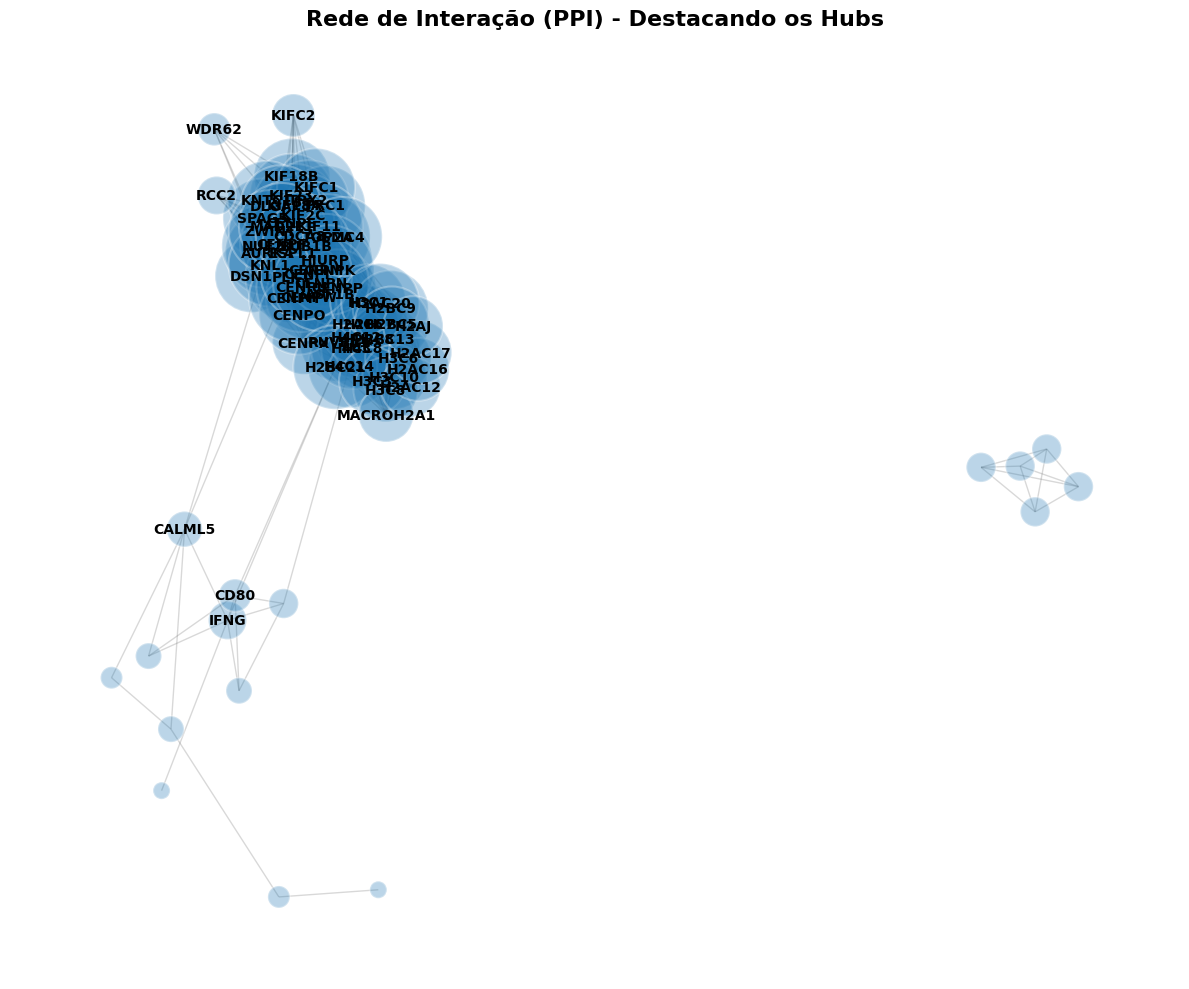

In [15]:
plt.figure(figsize=(12, 10))
plt.title("Rede de Interação (PPI) - Destacando os Hubs", fontsize=16, fontweight='bold')

positions = nx.spring_layout(G, k=0.15, iterations=50, seed=42)
degrees = dict(G.degree())
node_size = [50 + (degrees[node]*100) for node in G.nodes()]

nx.draw_networkx_edges(G, positions, alpha=0.3, edge_color='gray')
nx.draw_networkx_nodes(G, positions, node_size=node_size, node_color='tab:blue',
                       edgecolors='white', linewidths=1.5, alpha=0.3)


filtrated_labels = {node:node for node, grau in degrees.items() if grau > 4}
nx.draw_networkx_labels(G, positions, labels=filtrated_labels,
                        font_size=10, font_family='sans-serif', font_weight='bold')

plt.tight_layout()
plt.axis('off')
plt.show()

# Exportando Resultados

<font size=3>

Nesta última etapa, vamos consolidar tudo o que descobrimos. Criaremos um arquivo Excel contendo duas abas:
1. **Vias Enriquecidas:** Toda a estatística do `gseapy` mostrando quais maquinários a célula doente ativou.

2. **Alvos Terapêuticos (PPI):** O ranking das proteínas que formam a nossa Rede de Interação, ordenadas da mais conectada (o *Hub* principal) até a menos conectada.


In [18]:
file_name = "resultados_finais_brca.xlsx"

df_hubs = pd.DataFrame(list(degrees.items()), columns=['Proteina', 'Numero_de_Conexoes'])
df_hubs = df_hubs.sort_values(by='Numero_de_Conexoes', ascending=False)

df_hubs.head()

,Proteina,Numero_de_Conexoes
42,CENPN,47
33,HJURP,44
0,CENPM,43
43,CENPI,43
18,PLK1,43


In [19]:
with pd.ExcelWriter(file_name, engine='openpyxl') as writer:

    # Aba 1: toda a tabela do GSEApy (Vias, p-valores, genes envolvidos)
    enr.results.to_excel(writer, sheet_name='Vias_Enriquecidas', index=False)

    # Aba 2: tabela de Hubs recém-criada
    df_hubs.to_excel(writer, sheet_name='Alvos_Terapeuticos_PPI', index=False)

print(f"Análise concluída com sucesso! Os resultados foram salvos no arquivo: '{file_name}'")

Análise concluída com sucesso! Os resultados foram salvos no arquivo: 'resultados_finais_brca.xlsx'
